In [73]:
import pandas as pd
import numpy as np 
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

In [74]:
time_series_data = pd.read_csv("AirPassengers.xls")
time_series_data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [75]:
time_series_data.shape

(144, 2)

In [76]:
time_series_data["Month"] = pd.to_datetime(time_series_data["Month"])
time_series_data=time_series_data.set_index("Month")

In [77]:
time_series_data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


Text(0, 0.5, '#Passenger')

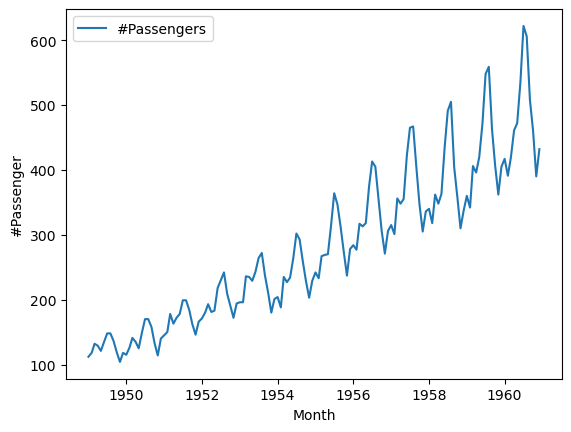

In [78]:
sns.lineplot(time_series_data)
plt.ylabel("#Passenger")

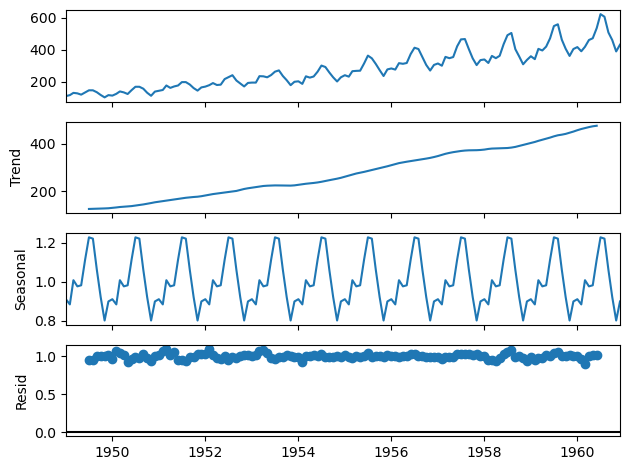

In [79]:
result = seasonal_decompose(time_series_data[["#Passengers"]],model="multiplicative",period=12)
result.plot()
plt.show()

In [80]:
pip install pymannkendall

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [81]:
import pymannkendall as mk
mk.original_test(time_series_data["#Passengers"])                                                                                                       

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(14.381610025544802), Tau=np.float64(0.8087606837606838), s=np.float64(8327.0), var_s=np.float64(335164.3333333333), slope=np.float64(2.451216287678477), intercept=np.float64(90.23803543098887))

In [82]:
#pvalue<0.5 theen reject h0. there is a trend present 

In [83]:
train_df=time_series_data[:int(time_series_data.shape[0]*0.7)]
test_df=time_series_data[int(time_series_data.shape[0]*0.7):]

In [84]:
train_df.head(5)

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [85]:
# Single Exponential Smoothing

from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(train_df)
model_single_fit = model.fit()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [86]:
forecast_single = model_single_fit.forecast(len(test_df))
print(forecast_single.head())

1957-05-01    348.0
1957-06-01    348.0
1957-07-01    348.0
1957-08-01    348.0
1957-09-01    348.0
Freq: MS, dtype: float64


In [87]:
model_single_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

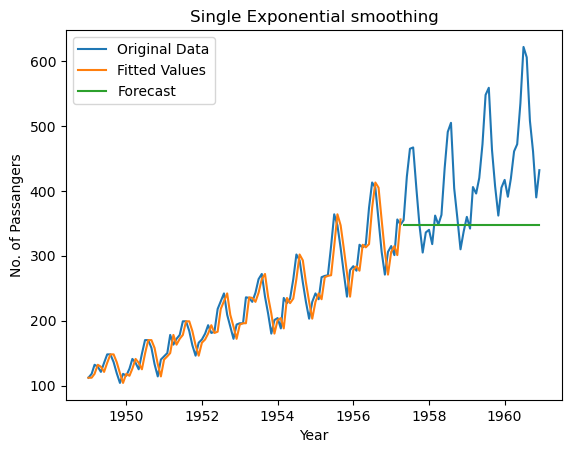

In [88]:
plt.plot(time_series_data, label = 'Original Data')
plt.plot(model_single_fit.fittedvalues, label = 'Fitted Values')
plt.plot(forecast_single, label = 'Forecast')
plt.xlabel('Year')
plt.ylabel('No. of Passangers')
plt.title('Single Exponential smoothing')
plt.legend()
plt.show()

In [89]:
# Double Exponential Smoothing

from statsmodels.tsa.api import Holt

model = Holt(train_df)
model_double_fit = model.fit()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [90]:
forecast_double = model_double_fit.forecast(len(test_df))
print(forecast_double.head())

1957-05-01    352.234329
1957-06-01    356.468659
1957-07-01    360.702988
1957-08-01    364.937317
1957-09-01    369.171647
Freq: MS, dtype: float64


In [91]:
model_double_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(0.006851678312691752),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(6.0),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

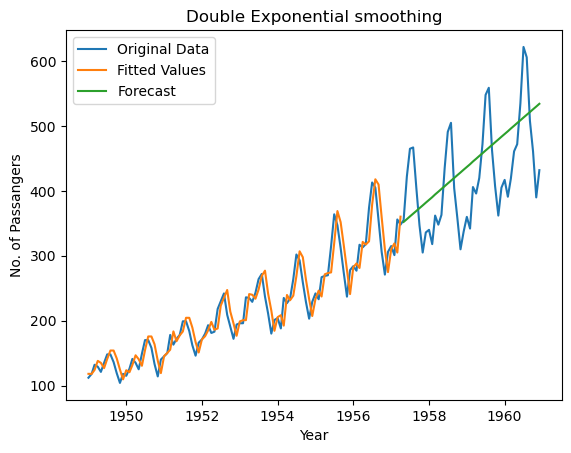

In [92]:
plt.plot(time_series_data, label = 'Original Data')
plt.plot(model_double_fit.fittedvalues, label = 'Fitted Values')
plt.plot(forecast_double, label = 'Forecast')
plt.xlabel('Year')
plt.ylabel('No. of Passangers')
plt.title('Double Exponential smoothing')
plt.legend()
plt.show()

In [93]:
# Triple Exponential Smoothing

from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_triple = ExponentialSmoothing(train_df, seasonal='add', seasonal_periods=12, trend='add')
model_triple_fit = model_triple.fit()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [94]:
model_double_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(0.006851678312691752),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(6.0),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

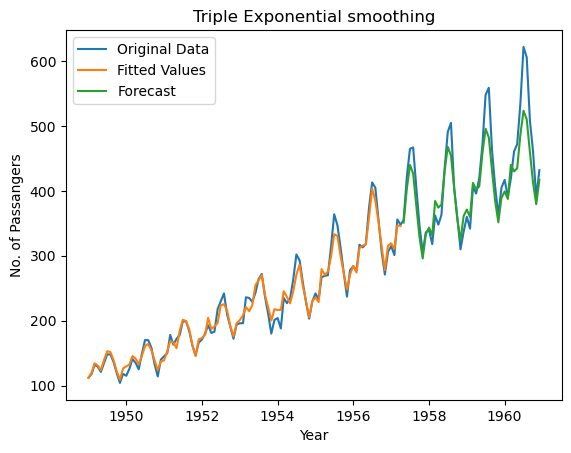

In [95]:
# graph
plt.plot(time_series_data, label = 'Original Data')
plt.plot(model_triple_fit.fittedvalues, label = 'Fitted Values')
plt.plot(model_triple_fit.forecast(len(test_df)), label = 'Forecast')
plt.xlabel('Year')
plt.ylabel('No. of Passangers')
plt.title('Triple Exponential smoothing')
plt.legend()
plt.show()

In [96]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple_mul = ExponentialSmoothing(train_df, seasonal='mul', seasonal_periods=12, trend='add')
model_triple_fit_mul = model_triple_mul.fit()
forecast_triple_mul = model_triple_fit_mul.forecast(len(test_df))


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [97]:
model_double_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(0.006851678312691752),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(6.0),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [103]:
forecast_triple = model_triple_fit.forecast(len(test_df))
print(forecast_triple.head())

forecast_triple_mul = model_triple_fit_mul.forecast(len(test_df))
print(forecast_triple_mul.head())

1957-05-01    351.239579
1957-06-01    403.308277
1957-07-01    439.937054
1957-08-01    426.800189
1957-09-01    375.973335
Freq: MS, dtype: float64
1957-05-01    351.239579
1957-06-01    403.308277
1957-07-01    439.937054
1957-08-01    426.800189
1957-09-01    375.973335
Freq: MS, dtype: float64


In [106]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
mape_test_add = mean_absolute_percentage_error(test_df['#Passengers'], forecast_triple)
print('MAPE for Test Data:', mape_test_add)


MAPE for Test Data: 0.053971281128541035


In [107]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
mape_test_mul = mean_absolute_percentage_error(test_df['#Passengers'], forecast_triple_mul)
print('MAPE for Test Data:', mape_test_mul)


MAPE for Test Data: 0.053971281128541035
